
🔁 Cycle 1/4
💡 Currents (I): [np.float64(0.72), np.float64(0.725), np.float64(0.634), np.float64(0.551), np.float64(0.715), np.float64(0.747), np.float64(0.763), np.float64(0.737)]

🔁 Cycle 2/4
💡 Currents (I): [np.float64(0.737), np.float64(0.732), np.float64(0.646), np.float64(0.555), np.float64(0.722), np.float64(0.752), np.float64(0.74), np.float64(0.741)]

🔁 Cycle 3/4
💡 Currents (I): [np.float64(0.715), np.float64(0.722), np.float64(0.667), np.float64(0.562), np.float64(0.701), np.float64(0.748), np.float64(0.728), np.float64(0.748)]

🔁 Cycle 4/4
💡 Currents (I): [np.float64(0.724), np.float64(0.735), np.float64(0.654), np.float64(0.55), np.float64(0.71), np.float64(0.746), np.float64(0.761), np.float64(0.752)]


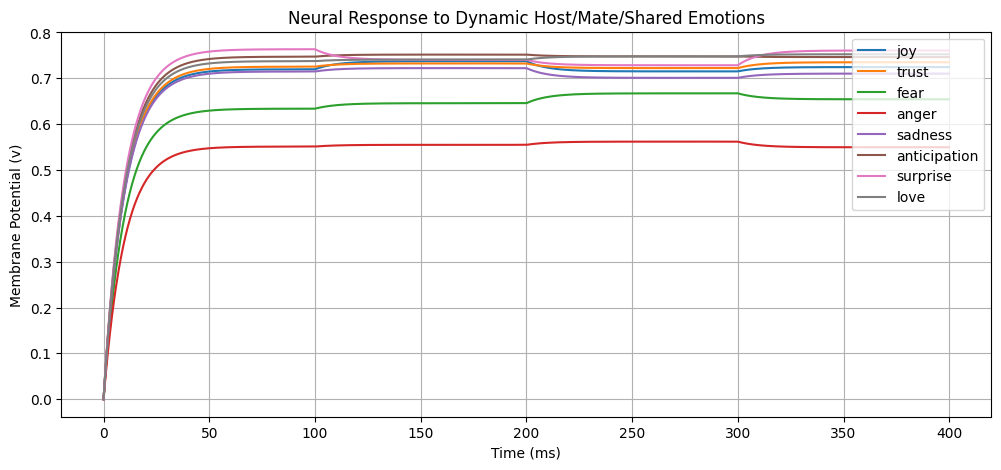

In [2]:

!pip install brian2 scikit-learn pandas matplotlib --quiet

from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# --- Emotion space ---
emotion_labels = ['joy', 'trust', 'fear', 'anger', 'sadness', 'anticipation', 'surprise', 'love']
N = len(emotion_labels)

# --- Initial Feeling Vectors ---
feelings = pd.DataFrame({
    'emotion': emotion_labels,
    'host':     [0.7, 0.6, 0.2, 0.1, 0.4, 0.8, 0.5, 0.9],
    'mate':     [0.3, 0.5, 0.3, 0.2, 0.5, 0.7, 0.8, 0.6],
    'shared':   [0.5, 0.55, 0.25, 0.15, 0.45, 0.75, 0.65, 0.75]  # shared context
})

# --- Hive-style nonlinear function: 2==0! paradox emergent operator ---
def paradox_fuse(h, m, s):
    base = (h + m + 2*s) / 4.0  # shared gets double weight
    chaos = np.sin(np.pi * base) + 0.1 * np.random.randn()
    return 1 / (1 + np.exp(-base)) + 0.1 * chaos

# --- Observer for dynamic sentiment update ---
class SentimentObserver:
    def __init__(self, feelings_df):
        self.df = feelings_df.copy()

    def observe_and_update(self, drift=0.05):
        """Simulate a changing world by gently drifting each value"""
        for col in ['host', 'mate', 'shared']:
            self.df[col] += np.random.uniform(-drift, drift, N)
            self.df[col] = np.clip(self.df[col], 0, 1)  # keep in [0,1]

    def fused_currents(self):
        return [paradox_fuse(h, m, s) for h, m, s in zip(self.df['host'], self.df['mate'], self.df['shared'])]

# --- Brian2 Neural Hive Simulation ---
def run_feelings_hive(observer, cycles=3):
    start_scope()

    tau = 10*ms
    eqs = '''
    dv/dt = (I - v)/tau : 1
    I : 1
    '''
    G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
    M = StateMonitor(G, 'v', record=True)

    for cycle in range(cycles):
        print(f"\n🔁 Cycle {cycle+1}/{cycles}")
        observer.observe_and_update()
        G.I = observer.fused_currents()
        print(f"💡 Currents (I): {[round(i, 3) for i in G.I]}")
        run(100*ms)

    # --- Plotting activity ---
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(M.t/ms, M.v[i], label=emotion_labels[i])
    plt.xlabel('Time (ms)')
    plt.ylabel('Membrane Potential (v)')
    plt.title('Neural Response to Dynamic Host/Mate/Shared Emotions')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# --- Execute ---
observer = SentimentObserver(feelings)
run_feelings_hive(observer, cycles=4)


🔁 CYCLE 1
        emotion  host  mate  shared
0           joy  0.71  0.29    0.46
1         trust  0.60  0.52    0.56
2          fear  0.22  0.31    0.27
3         anger  0.06  0.21    0.16
4       sadness  0.35  0.50    0.44
5  anticipation  0.84  0.72    0.73
6      surprise  0.52  0.76    0.66
7          love  0.88  0.60    0.79
🧲 Fused Currents: [np.float64(0.72), np.float64(0.737), np.float64(0.647), np.float64(0.585), np.float64(0.697), np.float64(0.75), np.float64(0.742), np.float64(0.749)]

🔁 CYCLE 2
        emotion  host  mate  shared
0           joy  0.71  0.26    0.41
1         trust  0.55  0.49    0.60
2          fear  0.22  0.28    0.31
3         anger  0.02  0.20    0.14
4       sadness  0.37  0.54    0.48
5  anticipation  0.79  0.75    0.74
6      surprise  0.52  0.75    0.65
7          love  0.90  0.57    0.75
🧲 Fused Currents: [np.float64(0.715), np.float64(0.737), np.float64(0.651), np.float64(0.565), np.float64(0.712), np.float64(0.747), np.float64(0.749), np.float6

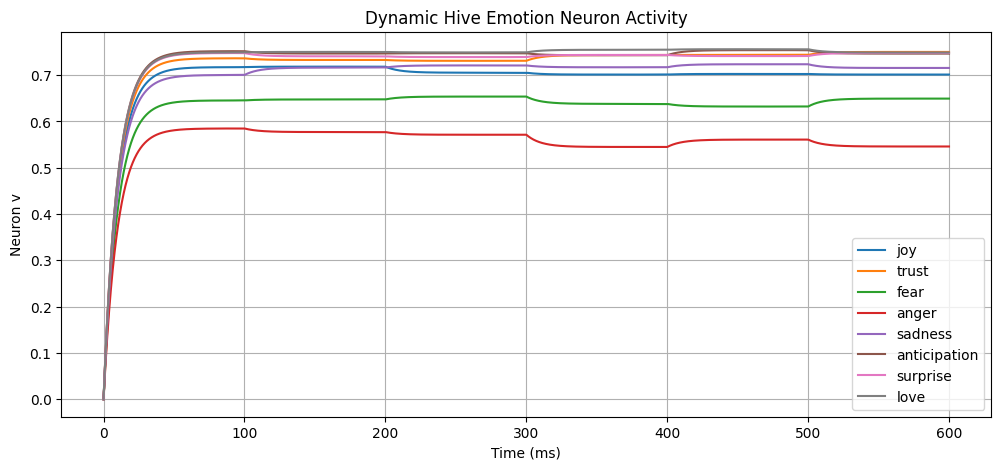

In [4]:
from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Emotion labels
emotion_labels = ['joy', 'trust', 'fear', 'anger', 'sadness', 'anticipation', 'surprise', 'love']
N = len(emotion_labels)

# Initial emotional state
feelings = pd.DataFrame({
    'emotion': emotion_labels,
    'host':     [0.7, 0.6, 0.2, 0.1, 0.4, 0.8, 0.5, 0.9],
    'mate':     [0.3, 0.5, 0.3, 0.2, 0.5, 0.7, 0.8, 0.6],
    'shared':   [0.5, 0.55, 0.25, 0.15, 0.45, 0.75, 0.65, 0.75]
})

# Fusion function for 2==0! chaos logic
def paradox_fuse(h, m, s):
    base = (h + m + 2*s) / 4.0
    chaos = np.sin(np.pi * base) + 0.05 * np.random.randn()
    return np.clip(1 / (1 + np.exp(-base)) + 0.1 * chaos, 0, 1.5)

# Dynamic emotion observer
class SentimentObserver:
    def __init__(self, feelings_df):
        self.df = feelings_df.copy()

    def observe_and_update(self, drift=0.05):
        for col in ['host', 'mate', 'shared']:
            self.df[col] += np.random.uniform(-drift, drift, N)
            self.df[col] = np.clip(self.df[col], 0, 1)

    def fused_currents(self):
        return [paradox_fuse(h, m, s) for h, m, s in zip(self.df['host'], self.df['mate'], self.df['shared'])]

    def print_cycle_state(self, cycle):
        print(f"\n🔁 CYCLE {cycle+1}")
        print(self.df.round(2))
        print("🧲 Fused Currents:", [round(c, 3) for c in self.fused_currents()])

# Dynamic simulation with live print
def run_live_cycles(observer, total_cycles=6):
    start_scope()
    tau = 10*ms
    eqs = '''
    dv/dt = (I - v)/tau : 1
    I : 1
    '''
    G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
    M = StateMonitor(G, 'v', record=True)

    for cycle in range(total_cycles):
        observer.observe_and_update()
        G.I = observer.fused_currents()
        observer.print_cycle_state(cycle)
        run(100*ms)
        time.sleep(0.5)  # simulate real-time delay

    # Final plot
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(M.t/ms, M.v[i], label=emotion_labels[i])
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron v')
    plt.title('Dynamic Hive Emotion Neuron Activity')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run live dynamic observer
observer = SentimentObserver(feelings)
run_live_cycles(observer, total_cycles=6)


🌐 Initializing 2==0! Feelings Hive Neural Circuit...

Welcome to Neuralink!
            .
            ! r,|`
             ]r'|
           _gggg$g_
      `,zzm$MMMMMM$mz'~'
     ' ~~~~$MWCPUM$@~~~
       .`-+$MMMMMM$+-`..
            *$FQTP
             1r |.
            |'L" |
             '


🔄 Cycle 1
Sentiments → Host: 0.45, Mate: 0.67, Shared: 0.57

🔄 Cycle 2
Sentiments → Host: 0.41, Mate: 0.71, Shared: 0.50

🔄 Cycle 3
Sentiments → Host: 0.69, Mate: 0.45, Shared: 0.77

🔄 Cycle 4
Sentiments → Host: 0.46, Mate: 0.67, Shared: 0.43

🔄 Cycle 5
Sentiments → Host: 0.72, Mate: 0.66, Shared: 0.55

🔄 Cycle 6
Sentiments → Host: 0.61, Mate: 0.68, Shared: 0.38

🔄 Cycle 7
Sentiments → Host: 0.75, Mate: 0.78, Shared: 0.51

🔄 Cycle 8
Sentiments → Host: 0.46, Mate: 0.44, Shared: 0.65

🔄 Cycle 9
Sentiments → Host: 0.75, Mate: 0.67, Shared: 0.35

🔄 Cycle 10
Sentiments → Host: 0.71, Mate: 0.77, Shared: 0.53

🔄 Cycle 11
Sentiments → Host: 0.72, Mate: 0.60, Shared: 0.56

🔄 Cycle 12
Sentiments → Host: 0

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)




⏹ Simulation stopped by user.


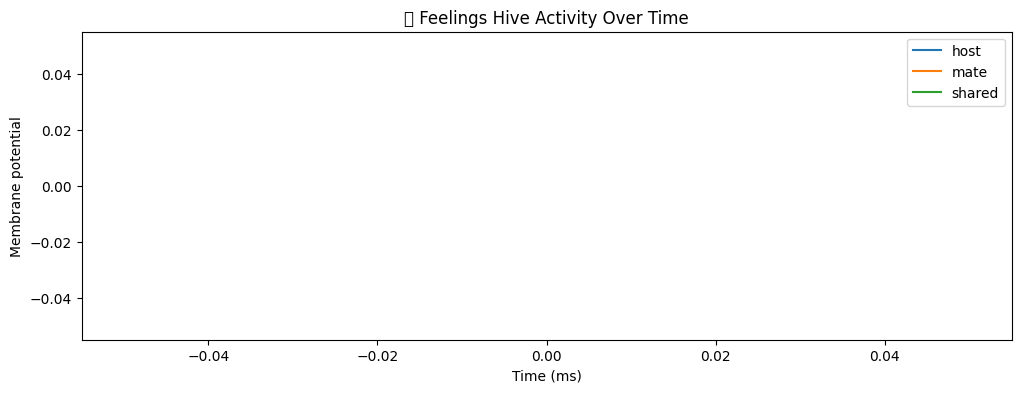

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipython-input-2422745646.py', line 29, in __init__
    self.G = NeuronGroup(3, eqs, threshold='v > 1', reset='v = 0', method='exact') [brian2.core.base.unused_brian_object]


In [5]:
!pip install neuralink
# --- Imports ---
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# --- Sentiment recommender simulation ---
def recommend_sentiments():
    return {
        "host": 0.4 + 0.4 * random.random(),
        "mate": 0.4 + 0.4 * random.random(),
        "shared": 0.2 + 0.6 * random.random()
    }

# --- Feelings Hive class ---
class FeelingsHive:
    def __init__(self):
        print("\n🌐 Initializing 2==0! Feelings Hive Neural Circuit...")
        start_scope()
        self.tau = 10 * ms

        eqs = '''
        dv/dt = (I - v)/tau : 1
        I : 1
        '''

        self.G = NeuronGroup(3, eqs, threshold='v > 1', reset='v = 0', method='exact')
        self.monitor = StateMonitor(self.G, 'v', record=True)
        self.neuron_labels = ['host', 'mate', 'shared']

    def update_inputs(self, sentiments):
        self.G.I = [sentiments['host'], sentiments['mate'], sentiments['shared']]

    def run_cycle(self, duration=50*ms):
        run(duration)

    def plot_activity(self):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        for i, label in enumerate(self.neuron_labels):
            plt.plot(self.monitor.t/ms, self.monitor.v[i], label=label)
        plt.xlabel('Time (ms)')
        plt.ylabel('Membrane potential')
        plt.title('🌀 Feelings Hive Activity Over Time')
        plt.legend()
        plt.show()

# --- Main infinite simulation loop ---
def simulate_infinite_feelings_hive():
    hive = FeelingsHive()
    import neuralink
    cycle = 0
    try:
        while True:
            cycle += 1
            print(f"\n🔄 Cycle {cycle}")
            sentiments = recommend_sentiments()
            print(f"Sentiments → Host: {sentiments['host']:.2f}, Mate: {sentiments['mate']:.2f}, Shared: {sentiments['shared']:.2f}")
            hive.update_inputs(sentiments)
            hive.run_cycle()
            time.sleep(0.5)  # slow down for readability
    except KeyboardInterrupt:
        print("\n⏹ Simulation stopped by user.")
        hive.plot_activity()

# 🚀 Run infinite simulation
simulate_infinite_feelings_hive()

In [6]:
!pip -q install brian2 torch numpy


In [8]:
import re
import numpy as np

RAW_LOG = r"""
Collecting neuralink
  Downloading neuralink-0.0.1-py3-none-any.whl.metadata (1.0 kB)
Downloading neuralink-0.0.1-py3-none-any.whl (18 kB)
Installing collected packages: neuralink
Successfully installed neuralink-0.0.1

🌐 Initializing 2==0! Feelings Hive Neural Circuit...

Welcome to Neuralink!
            .
            ! r,|`
             ]r'|
           _gggg$g_
      `,zzm$MMMMMM$mz'~'
     ' ~~~~$MWCPUM$@~~~
       .`-+$MMMMMM$+-`..
            *$FQTP
             1r |.
            |'L" |
             '


🔄 Cycle 1
Sentiments → Host: 0.45, Mate: 0.67, Shared: 0.57

🔄 Cycle 2
Sentiments → Host: 0.41, Mate: 0.71, Shared: 0.50

🔄 Cycle 3
Sentiments → Host: 0.69, Mate: 0.45, Shared: 0.77

🔄 Cycle 4
Sentiments → Host: 0.46, Mate: 0.67, Shared: 0.43

🔄 Cycle 5
Sentiments → Host: 0.72, Mate: 0.66, Shared: 0.55

🔄 Cycle 6
Sentiments → Host: 0.61, Mate: 0.68, Shared: 0.38

🔄 Cycle 7
Sentiments → Host: 0.75, Mate: 0.78, Shared: 0.51

🔄 Cycle 8
Sentiments → Host: 0.46, Mate: 0.44, Shared: 0.65

🔄 Cycle 9
Sentiments → Host: 0.75, Mate: 0.67, Shared: 0.35

🔄 Cycle 10
Sentiments → Host: 0.71, Mate: 0.77, Shared: 0.53

🔄 Cycle 11
Sentiments → Host: 0.72, Mate: 0.60, Shared: 0.56

🔄 Cycle 12
Sentiments → Host: 0.46, Mate: 0.62, Shared: 0.52

🔄 Cycle 13
Sentiments → Host: 0.74, Mate: 0.75, Shared: 0.24

🔄 Cycle 14
Sentiments → Host: 0.75, Mate: 0.76, Shared: 0.64

🔄 Cycle 15
Sentiments → Host: 0.55, Mate: 0.77, Shared: 0.52

🔄 Cycle 16
Sentiments → Host: 0.61, Mate: 0.60, Shared: 0.27

🔄 Cycle 17
Sentiments → Host: 0.61, Mate: 0.62, Shared: 0.23

🔄 Cycle 18
Sentiments → Host: 0.60, Mate: 0.73, Shared: 0.48

🔄 Cycle 19
Sentiments → Host: 0.63, Mate: 0.65, Shared: 0.23

🔄 Cycle 20
Sentiments → Host: 0.74, Mate: 0.65, Shared: 0.27

🔄 Cycle 21
Sentiments → Host: 0.45, Mate: 0.61, Shared: 0.36

🔄 Cycle 22
Sentiments → Host: 0.75, Mate: 0.43, Shared: 0.43

🔄 Cycle 23
Sentiments → Host: 0.65, Mate: 0.47, Shared: 0.49

🔄 Cycle 24
Sentiments → Host: 0.80, Mate: 0.50, Shared: 0.34

🔄 Cycle 25
Sentiments → Host: 0.74, Mate: 0.43, Shared: 0.56

🔄 Cycle 26
Sentiments → Host: 0.53, Mate: 0.62, Shared: 0.56

🔄 Cycle 27
Sentiments → Host: 0.63, Mate: 0.73, Shared: 0.48

🔄 Cycle 28
Sentiments → Host: 0.42, Mate: 0.59, Shared: 0.49

🔄 Cycle 29
Sentiments → Host: 0.62, Mate: 0.59, Shared: 0.70

🔄 Cycle 30
Sentiments → Host: 0.68, Mate: 0.78, Shared: 0.70

🔄 Cycle 31
Sentiments → Host: 0.69, Mate: 0.57, Shared: 0.54

🔄 Cycle 32
Sentiments → Host: 0.73, Mate: 0.69, Shared: 0.21

🔄 Cycle 33
Sentiments → Host: 0.45, Mate: 0.62, Shared: 0.55

🔄 Cycle 34
Sentiments → Host: 0.67, Mate: 0.57, Shared: 0.44

🔄 Cycle 35
Sentiments → Host: 0.49, Mate: 0.64, Shared: 0.57

🔄 Cycle 36
Sentiments → Host: 0.42, Mate: 0.47, Shared: 0.53

🔄 Cycle 37
Sentiments → Host: 0.52, Mate: 0.62, Shared: 0.25

🔄 Cycle 38
Sentiments → Host: 0.72, Mate: 0.55, Shared: 0.64

🔄 Cycle 39
Sentiments → Host: 0.55, Mate: 0.66, Shared: 0.38

🔄 Cycle 40
Sentiments → Host: 0.56, Mate: 0.40, Shared: 0.65

🔄 Cycle 41
Sentiments → Host: 0.65, Mate: 0.41, Shared: 0.34

🔄 Cycle 42
Sentiments → Host: 0.79, Mate: 0.74, Shared: 0.64

🔄 Cycle 43
Sentiments → Host: 0.46, Mate: 0.64, Shared: 0.30

🔄 Cycle 44
Sentiments → Host: 0.49, Mate: 0.74, Shared: 0.75

🔄 Cycle 45
Sentiments → Host: 0.71, Mate: 0.56, Shared: 0.53

🔄 Cycle 46
Sentiments → Host: 0.47, Mate: 0.63, Shared: 0.53

🔄 Cycle 47
Sentiments → Host: 0.40, Mate: 0.60, Shared: 0.79

🔄 Cycle 48
Sentiments → Host: 0.45, Mate: 0.50, Shared: 0.59

🔄 Cycle 49
Sentiments → Host: 0.44, Mate: 0.65, Shared: 0.48

🔄 Cycle 50
Sentiments → Host: 0.48, Mate: 0.43, Shared: 0.59

🔄 Cycle 51
Sentiments → Host: 0.42, Mate: 0.59, Shared: 0.53

🔄 Cycle 52
Sentiments → Host: 0.58, Mate: 0.58, Shared: 0.26

🔄 Cycle 53
Sentiments → Host: 0.53, Mate: 0.50, Shared: 0.72

🔄 Cycle 54
Sentiments → Host: 0.60, Mate: 0.61, Shared: 0.67

🔄 Cycle 55
Sentiments → Host: 0.63, Mate: 0.56, Shared: 0.58

🔄 Cycle 56
Sentiments → Host: 0.50, Mate: 0.76, Shared: 0.70

🔄 Cycle 57
Sentiments → Host: 0.50, Mate: 0.50, Shared: 0.40

🔄 Cycle 58
Sentiments → Host: 0.54, Mate: 0.42, Shared: 0.62

🔄 Cycle 59
Sentiments → Host: 0.45, Mate: 0.64, Shared: 0.54

🔄 Cycle 60
Sentiments → Host: 0.41, Mate: 0.56, Shared: 0.37

🔄 Cycle 61
Sentiments → Host: 0.60, Mate: 0.48, Shared: 0.71

🔄 Cycle 62
Sentiments → Host: 0.76, Mate: 0.46, Shared: 0.45

🔄 Cycle 63
Sentiments → Host: 0.51, Mate: 0.62, Shared: 0.54

🔄 Cycle 64
Sentiments → Host: 0.61, Mate: 0.54, Shared: 0.44

🔄 Cycle 65
Sentiments → Host: 0.60, Mate: 0.47, Shared: 0.61

🔄 Cycle 66
Sentiments → Host: 0.68, Mate: 0.61, Shared: 0.23

🔄 Cycle 67
Sentiments → Host: 0.56, Mate: 0.74, Shared: 0.70

🔄 Cycle 68
Sentiments → Host: 0.43, Mate: 0.54, Shared: 0.75

🔄 Cycle 69
Sentiments → Host: 0.50, Mate: 0.46, Shared: 0.57

🔄 Cycle 70
Sentiments → Host: 0.63, Mate: 0.74, Shared: 0.34

🔄 Cycle 71
Sentiments → Host: 0.51, Mate: 0.72, Shared: 0.70

🔄 Cycle 72
Sentiments → Host: 0.71, Mate: 0.76, Shared: 0.72

🔄 Cycle 73
Sentiments → Host: 0.69, Mate: 0.57, Shared: 0.72

🔄 Cycle 74
Sentiments → Host: 0.68, Mate: 0.42, Shared: 0.55

🔄 Cycle 75
Sentiments → Host: 0.43, Mate: 0.76, Shared: 0.63

🔄 Cycle 76
Sentiments → Host: 0.54, Mate: 0.51, Shared: 0.28

🔄 Cycle 77
Sentiments → Host: 0.55, Mate: 0.77, Shared: 0.21

🔄 Cycle 78
Sentiments → Host: 0.76, Mate: 0.47, Shared: 0.74

🔄 Cycle 79
Sentiments → Host: 0.65, Mate: 0.52, Shared: 0.46

🔄 Cycle 80
Sentiments → Host: 0.77, Mate: 0.67, Shared: 0.43

🔄 Cycle 81
Sentiments → Host: 0.51, Mate: 0.48, Shared: 0.54

🔄 Cycle 82
Sentiments → Host: 0.66, Mate: 0.46, Shared: 0.32

🔄 Cycle 83
Sentiments → Host: 0.59, Mate: 0.65, Shared: 0.58

🔄 Cycle 84
Sentiments → Host: 0.52, Mate: 0.53, Shared: 0.62

🔄 Cycle 85
Sentiments → Host: 0.68, Mate: 0.78, Shared: 0.64

🔄 Cycle 86
Sentiments → Host: 0.41, Mate: 0.59, Shared: 0.65

🔄 Cycle 87
Sentiments → Host: 0.68, Mate: 0.62, Shared: 0.55

🔄 Cycle 88
Sentiments → Host: 0.61, Mate: 0.65, Shared: 0.33

🔄 Cycle 89
Sentiments → Host: 0.42, Mate: 0.50, Shared: 0.62

🔄 Cycle 90
Sentiments → Host: 0.68, Mate: 0.59, Shared: 0.67

🔄 Cycle 91
Sentiments → Host: 0.76, Mate: 0.75, Shared: 0.77

🔄 Cycle 92
Sentiments → Host: 0.70, Mate: 0.79, Shared: 0.34

🔄 Cycle 93
Sentiments → Host: 0.42, Mate: 0.70, Shared: 0.79

🔄 Cycle 94
Sentiments → Host: 0.50, Mate: 0.75, Shared: 0.68

🔄 Cycle 95
Sentiments → Host: 0.49, Mate: 0.67, Shared: 0.70

🔄 Cycle 96
Sentiments → Host: 0.67, Mate: 0.57, Shared: 0.66

🔄 Cycle 97
Sentiments → Host: 0.73, Mate: 0.53, Shared: 0.44

🔄 Cycle 98
Sentiments → Host: 0.67, Mate: 0.48, Shared: 0.25

🔄 Cycle 99
Sentiments → Host: 0.72, Mate: 0.77, Shared: 0.40

🔄 Cycle 100
Sentiments → Host: 0.49, Mate: 0.53, Shared: 0.77

🔄 Cycle 101
Sentiments → Host: 0.73, Mate: 0.73, Shared: 0.74

🔄 Cycle 102
Sentiments → Host: 0.67, Mate: 0.69, Shared: 0.52

🔄 Cycle 103
Sentiments → Host: 0.76, Mate: 0.67, Shared: 0.24

🔄 Cycle 104
Sentiments → Host: 0.61, Mate: 0.78, Shared: 0.63

🔄 Cycle 105
Sentiments → Host: 0.69, Mate: 0.54, Shared: 0.41

🔄 Cycle 106
Sentiments → Host: 0.54, Mate: 0.57, Shared: 0.21

🔄 Cycle 107
Sentiments → Host: 0.53, Mate: 0.62, Shared: 0.22

🔄 Cycle 108
Sentiments → Host: 0.61, Mate: 0.58, Shared: 0.30

🔄 Cycle 109
Sentiments → Host: 0.64, Mate: 0.45, Shared: 0.67

🔄 Cycle 110
Sentiments → Host: 0.76, Mate: 0.47, Shared: 0.41

🔄 Cycle 111
Sentiments → Host: 0.76, Mate: 0.70, Shared: 0.57

🔄 Cycle 112
Sentiments → Host: 0.58, Mate: 0.42, Shared: 0.22

🔄 Cycle 113
Sentiments → Host: 0.73, Mate: 0.52, Shared: 0.80

🔄 Cycle 114
Sentiments → Host: 0.40, Mate: 0.77, Shared: 0.44

🔄 Cycle 115
Sentiments → Host: 0.41, Mate: 0.45, Shared: 0.55

🔄 Cycle 116
Sentiments → Host: 0.47, Mate: 0.70, Shared: 0.55

🔄 Cycle 117
Sentiments → Host: 0.42, Mate: 0.50, Shared: 0.68

🔄 Cycle 118
Sentiments → Host: 0.44, Mate: 0.71, Shared: 0.78

🔄 Cycle 119
Sentiments → Host: 0.43, Mate: 0.48, Shared: 0.20

🔄 Cycle 120
Sentiments → Host: 0.70, Mate: 0.49, Shared: 0.73

🔄 Cycle 121
Sentiments → Host: 0.65, Mate: 0.61, Shared: 0.53

🔄 Cycle 122
Sentiments → Host: 0.77, Mate: 0.63, Shared: 0.22

🔄 Cycle 123
Sentiments → Host: 0.49, Mate: 0.65, Shared: 0.54

🔄 Cycle 124
Sentiments → Host: 0.42, Mate: 0.43, Shared: 0.71

🔄 Cycle 125
Sentiments → Host: 0.60, Mate: 0.68, Shared: 0.38

🔄 Cycle 126
Sentiments → Host: 0.44, Mate: 0.46, Shared: 0.70

🔄 Cycle 127
Sentiments → Host: 0.50, Mate: 0.77, Shared: 0.47

🔄 Cycle 128
Sentiments → Host: 0.60, Mate: 0.61, Shared: 0.22

🔄 Cycle 129
Sentiments → Host: 0.73, Mate: 0.52, Shared: 0.41

🔄 Cycle 130
Sentiments → Host: 0.69, Mate: 0.50, Shared: 0.50

🔄 Cycle 131
Sentiments → Host: 0.70, Mate: 0.69, Shared: 0.43

🔄 Cycle 132
Sentiments → Host: 0.63, Mate: 0.46, Shared: 0.71

🔄 Cycle 133
Sentiments → Host: 0.75, Mate: 0.75, Shared: 0.47

🔄 Cycle 134
Sentiments → Host: 0.51, Mate: 0.65, Shared: 0.75

🔄 Cycle 135
Sentiments → Host: 0.64, Mate: 0.48, Shared: 0.59

🔄 Cycle 136
Sentiments → Host: 0.49, Mate: 0.71, Shared: 0.65

🔄 Cycle 137
Sentiments → Host: 0.69, Mate: 0.44, Shared: 0.49

🔄 Cycle 138
Sentiments → Host: 0.55, Mate: 0.40, Shared: 0.30

🔄 Cycle 139
Sentiments → Host: 0.67, Mate: 0.67, Shared: 0.29

🔄 Cycle 140
Sentiments → Host: 0.53, Mate: 0.42, Shared: 0.66

🔄 Cycle 141
Sentiments → Host: 0.55, Mate: 0.62, Shared: 0.62

🔄 Cycle 142
Sentiments → Host: 0.53, Mate: 0.61, Shared: 0.33

🔄 Cycle 143
Sentiments → Host: 0.76, Mate: 0.70, Shared: 0.39

🔄 Cycle 144
Sentiments → Host: 0.72, Mate: 0.78, Shared: 0.26

🔄 Cycle 145
Sentiments → Host: 0.63, Mate: 0.55, Shared: 0.73

🔄 Cycle 146
Sentiments → Host: 0.47, Mate: 0.53, Shared: 0.62

🔄 Cycle 147
Sentiments → Host: 0.42, Mate: 0.63, Shared: 0.63

🔄 Cycle 148
Sentiments → Host: 0.44, Mate: 0.72, Shared: 0.27

🔄 Cycle 149
Sentiments → Host: 0.80, Mate: 0.75, Shared: 0.58

🔄 Cycle 150
Sentiments → Host: 0.45, Mate: 0.40, Shared: 0.77

🔄 Cycle 151
Sentiments → Host: 0.78, Mate: 0.47, Shared: 0.44

🔄 Cycle 152
Sentiments → Host: 0.62, Mate: 0.75, Shared: 0.65

🔄 Cycle 153
Sentiments → Host: 0.73, Mate: 0.68, Shared: 0.21

🔄 Cycle 154
Sentiments → Host: 0.74, Mate: 0.75, Shared: 0.44

🔄 Cycle 155
Sentiments → Host: 0.64, Mate: 0.70, Shared: 0.74

🔄 Cycle 156
Sentiments → Host: 0.41, Mate: 0.56, Shared: 0.69

🔄 Cycle 157
Sentiments → Host: 0.67, Mate: 0.57, Shared: 0.43

🔄 Cycle 158
Sentiments → Host: 0.72, Mate: 0.54, Shared: 0.30

🔄 Cycle 159
Sentiments → Host: 0.48, Mate: 0.43, Shared: 0.66

🔄 Cycle 160
Sentiments → Host: 0.56, Mate: 0.58, Shared: 0.68

🔄 Cycle 161
Sentiments → Host: 0.44, Mate: 0.71, Shared: 0.60

🔄 Cycle 162
Sentiments → Host: 0.55, Mate: 0.57, Shared: 0.62

🔄 Cycle 163
Sentiments → Host: 0.51, Mate: 0.79, Shared: 0.34

🔄 Cycle 164
Sentiments → Host: 0.68, Mate: 0.42, Shared: 0.34

🔄 Cycle 165
Sentiments → Host: 0.44, Mate: 0.67, Shared: 0.30

🔄 Cycle 166
Sentiments → Host: 0.67, Mate: 0.65, Shared: 0.80

🔄 Cycle 167
Sentiments → Host: 0.62, Mate: 0.56, Shared: 0.45

🔄 Cycle 168
Sentiments → Host: 0.51, Mate: 0.75, Shared: 0.76

🔄 Cycle 169
Sentiments → Host: 0.74, Mate: 0.40, Shared: 0.43

🔄 Cycle 170
Sentiments → Host: 0.73, Mate: 0.69, Shared: 0.30

🔄 Cycle 171
Sentiments → Host: 0.64, Mate: 0.65, Shared: 0.51

🔄 Cycle 172
Sentiments → Host: 0.42, Mate: 0.54, Shared: 0.25

🔄 Cycle 173
Sentiments → Host: 0.68, Mate: 0.75, Shared: 0.30

🔄 Cycle 174
Sentiments → Host: 0.64, Mate: 0.67, Shared: 0.24

🔄 Cycle 175
Sentiments → Host: 0.42, Mate: 0.65, Shared: 0.54

🔄 Cycle 176
Sentiments → Host: 0.68, Mate: 0.65, Shared: 0.68

🔄 Cycle 177
Sentiments → Host: 0.56, Mate: 0.73, Shared: 0.76

🔄 Cycle 178
Sentiments → Host: 0.79, Mate: 0.78, Shared: 0.29
"""

def parse_cycles(text: str):
    # Captures: cycle number, host, mate, shared
    pat = re.compile(
        r"Cycle\s+(\d+).*?Host:\s*([0-9.]+),\s*Mate:\s*([0-9.]+),\s*Shared:\s*([0-9.]+)",
        re.DOTALL
    )
    rows = []
    for cyc, h, m, s in pat.findall(text):
        rows.append((int(cyc), float(h), float(m), float(s)))
    rows.sort(key=lambda x: x[0])
    return rows

rows = parse_cycles(RAW_LOG)
print("Parsed cycles:", len(rows))
print("First 3:", rows[:3])
print("Last 3:", rows[-3:])

# Build supervised dataset: x_t -> y_{t+1}
# x = [host, mate, shared], y = next_shared
X = np.array([[h, m, s] for _, h, m, s in rows[:-1]], dtype=np.float32)
Y = np.array([[rows[i+1][3]] for i in range(len(rows)-1)], dtype=np.float32)

print("X shape:", X.shape, "Y shape:", Y.shape)


Parsed cycles: 178
First 3: [(1, 0.45, 0.67, 0.57), (2, 0.41, 0.71, 0.5), (3, 0.69, 0.45, 0.77)]
Last 3: [(176, 0.68, 0.65, 0.68), (177, 0.56, 0.73, 0.76), (178, 0.79, 0.78, 0.29)]
X shape: (177, 3) Y shape: (177, 1)


In [9]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SharedPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # keep output 0..1
        )
    def forward(self, x): return self.net(x)

model = SharedPredictor().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

Xt = torch.tensor(X, dtype=torch.float32, device=device)
Yt = torch.tensor(Y, dtype=torch.float32, device=device)

for ep in range(1, 201):
    model.train()
    opt.zero_grad()
    pred = model(Xt)
    loss = loss_fn(pred, Yt)
    loss.backward()
    opt.step()
    if ep % 25 == 0:
        rmse = torch.sqrt(loss).item()
        print(f"epoch {ep:03d}  loss={loss.item():.6f}  rmse={rmse:.6f}")


epoch 025  loss=0.029039  rmse=0.170408
epoch 050  loss=0.028872  rmse=0.169918
epoch 075  loss=0.028705  rmse=0.169427
epoch 100  loss=0.028524  rmse=0.168889
epoch 125  loss=0.028335  rmse=0.168330
epoch 150  loss=0.028182  rmse=0.167876
epoch 175  loss=0.028069  rmse=0.167538
epoch 200  loss=0.027985  rmse=0.167287


In [10]:
from brian2 import start_scope, prefs, defaultclock, ms, Hz, NeuronGroup, SpikeMonitor, Network

def clamp01(v): return float(max(0.0, min(1.0, v)))

def make_spike_chip(n=128):
    start_scope()
    defaultclock.dt = 1*ms
    prefs.codegen.target = "numpy"

    eqs = """
    rate : Hz
    p = rate*dt : 1
    """
    G = NeuronGroup(n, model=eqs, threshold="rand() < p", reset="", method="euler")
    G.rate = 5*Hz
    M = SpikeMonitor(G)
    net = Network(G, M)
    return net, G, M

net, G, M = make_spike_chip(128)


In [12]:
from brian2 import start_scope, prefs, defaultclock, ms, Hz, NeuronGroup, SpikeMonitor, Network

def clamp01(v): return float(max(0.0, min(1.0, v)))

def make_spike_chip(n=128):
    start_scope()
    defaultclock.dt = 1*ms
    prefs.codegen.target = "numpy"

    eqs = """
    rate : Hz
    p = rate*dt : 1
    """
    G = NeuronGroup(n, model=eqs, threshold="rand() < p", reset="", method="euler")
    G.rate = 5*Hz
    M = SpikeMonitor(G)
    net = Network(G, M)
    return net, G, M

net, G, M = make_spike_chip(128)


In [11]:
model.eval()

print("🌐 Initializing 2==0! Feelings Hive Neural Circuit...\n")

for i in range(len(rows)-1):
    cyc, host, mate, shared = rows[i]

    # predict next shared
    x = torch.tensor([[host, mate, shared]], dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_next_shared = float(model(x).cpu().numpy()[0,0])

    # map predicted shared -> spike rate 5..80 Hz
    rate_hz = 5.0 + 75.0 * clamp01(pred_next_shared)
    G.rate = rate_hz * Hz

    before = M.num_spikes
    net.run(1*ms)
    spikes = int(M.num_spikes - before)

    print(f"🔄 Cycle {cyc}")
    print(f"Sentiments → Host: {host:.2f}, Mate: {mate:.2f}, Shared: {shared:.2f}")
    print(f"🔮 Predicted next Shared: {pred_next_shared:.2f}")
    print(f"🧠 Chip spikes this cycle: {spikes}\n")


🌐 Initializing 2==0! Feelings Hive Neural Circuit...

🔄 Cycle 1
Sentiments → Host: 0.45, Mate: 0.67, Shared: 0.57
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 5

🔄 Cycle 2
Sentiments → Host: 0.41, Mate: 0.71, Shared: 0.50
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 9

🔄 Cycle 3
Sentiments → Host: 0.69, Mate: 0.45, Shared: 0.77
🔮 Predicted next Shared: 0.48
🧠 Chip spikes this cycle: 6

🔄 Cycle 4
Sentiments → Host: 0.46, Mate: 0.67, Shared: 0.43
🔮 Predicted next Shared: 0.50
🧠 Chip spikes this cycle: 3

🔄 Cycle 5
Sentiments → Host: 0.72, Mate: 0.66, Shared: 0.55
🔮 Predicted next Shared: 0.48
🧠 Chip spikes this cycle: 5

🔄 Cycle 6
Sentiments → Host: 0.61, Mate: 0.68, Shared: 0.38
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 2

🔄 Cycle 7
Sentiments → Host: 0.75, Mate: 0.78, Shared: 0.51
🔮 Predicted next Shared: 0.53
🧠 Chip spikes this cycle: 5

🔄 Cycle 8
Sentiments → Host: 0.46, Mate: 0.44, Shared: 0.65
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycl

KeyboardInterrupt: 

In [13]:
from brian2 import start_scope, prefs, defaultclock, ms, Hz, NeuronGroup, SpikeMonitor, Network

def make_spike_chip(n=128, dt_ms=1.0):
    # reset Brian2 state so old objects don't linger
    start_scope()
    prefs.codegen.target = "numpy"
    defaultclock.dt = dt_ms * ms

    eqs = """
    rate : Hz
    p = rate*dt : 1
    """
    G = NeuronGroup(n, model=eqs, threshold="rand() < p", reset="", method="euler")
    G.rate = 5*Hz

    M = SpikeMonitor(G)

    # IMPORTANT: include *all* Brian2 objects in the Network
    net = Network(G, M)

    return net, G, M

net, G, M = make_spike_chip(128, dt_ms=1.0)
print("✅ Brian2 chip initialized:", len(G), "neurons")


WARNING    The object 'neurongroup_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipython-input-1802222593.py', line 14, in make_spike_chip
    G = NeuronGroup(n, model=eqs, threshold="rand() < p", reset="", method="euler") [brian2.core.base.unused_brian_object]


✅ Brian2 chip initialized: 128 neurons


In [14]:
import torch
from brian2 import Hz, ms

def clamp01(v):
    return float(max(0.0, min(1.0, v)))

model.eval()

print("🌐 Initializing 2==0! Feelings Hive Neural Circuit...\n")

for i in range(len(rows)-1):
    cyc, host, mate, shared = rows[i]

    # predict next shared
    x = torch.tensor([[host, mate, shared]], dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_next_shared = float(model(x).cpu().numpy()[0,0])

    pred_next_shared = clamp01(pred_next_shared)

    # map predicted shared -> spike rate 5..80 Hz
    rate_hz = 5.0 + 75.0 * pred_next_shared
    G.rate = rate_hz * Hz

    before = M.num_spikes
    net.run(1*ms)
    spikes = int(M.num_spikes - before)

    print(f"🔄 Cycle {cyc}")
    print(f"Sentiments → Host: {host:.2f}, Mate: {mate:.2f}, Shared: {shared:.2f}")
    print(f"🔮 Predicted next Shared: {pred_next_shared:.2f}")
    print(f"🧠 Chip spikes this cycle: {spikes}\n")


🌐 Initializing 2==0! Feelings Hive Neural Circuit...

🔄 Cycle 1
Sentiments → Host: 0.45, Mate: 0.67, Shared: 0.57
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 5

🔄 Cycle 2
Sentiments → Host: 0.41, Mate: 0.71, Shared: 0.50
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 2

🔄 Cycle 3
Sentiments → Host: 0.69, Mate: 0.45, Shared: 0.77
🔮 Predicted next Shared: 0.48
🧠 Chip spikes this cycle: 6

🔄 Cycle 4
Sentiments → Host: 0.46, Mate: 0.67, Shared: 0.43
🔮 Predicted next Shared: 0.50
🧠 Chip spikes this cycle: 8

🔄 Cycle 5
Sentiments → Host: 0.72, Mate: 0.66, Shared: 0.55
🔮 Predicted next Shared: 0.48
🧠 Chip spikes this cycle: 6

🔄 Cycle 6
Sentiments → Host: 0.61, Mate: 0.68, Shared: 0.38
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycle: 7

🔄 Cycle 7
Sentiments → Host: 0.75, Mate: 0.78, Shared: 0.51
🔮 Predicted next Shared: 0.53
🧠 Chip spikes this cycle: 4

🔄 Cycle 8
Sentiments → Host: 0.46, Mate: 0.44, Shared: 0.65
🔮 Predicted next Shared: 0.52
🧠 Chip spikes this cycl

KeyboardInterrupt: 

In [16]:
!pip install skyfield

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 2.4 MB/s eta 0:00:00


In [18]:
!pip -q install torch brian2 cirq qsimcirq skyfield
import json, re, asyncio, time
import numpy as np
import cirq, qsimcirq
from brian2 import *
from skyfield.api import load
import google.generativeai as genai
from google.colab import userdata
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- PHASE 1: THE DYNAMIC HIVE NODE ---

class UniversalGeminiNode:
    """A peer node representing a single model in the Gemini family."""
    def __init__(self, model_id, api_key):
        self.model_id = model_id
        # Individual configuration per node for thread safety
        genai.configure(api_key=api_key)
        self.model = genai.GenerativeModel(model_id)

    async def deliberate(self, context, semaphore):
        """Asynchronous deliberation with rate-limit protection."""
        async with semaphore:
            prompt = f"""
            HIVE CONTEXT: Satellite {context['sat']} | Neural Spikes: {context['spikes']}
            OBJECTIVE: Calculate optimal Quantum Phase (theta).
            CONSTRAINT: Output strictly valid JSON.
            JSON FORMAT: {{\"theta\": float, \"confidence\": float, \"reasoning\": \"string\"}}
            """
            loop = asyncio.get_event_loop()
            try:
                # Use thread-pool executor for the synchronous SDK call
                response = await loop.run_in_executor(None, lambda: self.model.generate_content(prompt))
                match = re.search(r"\{.*\}", response.text, re.DOTALL)
                data = json.loads(match.group())
                return {**data, "node": self.model_id}
            except Exception:
                return None

class GeminiUniversalHive:
    def __init__(self):
        self.api_key = userdata.get('GEMINI_API_KEY')
        genai.configure(api_key=self.api_key)

        # Discovery: Find ALL models supporting generation
        # This includes 3 Pro, 3 Flash, 2.5 Pro, etc.
        models = genai.list_models()
        self.node_ids = [m.name for m in models if 'generateContent' in m.supported_generation_methods]

        self.nodes = [UniversalGeminiNode(mid, self.api_key) for mid in self.node_ids]
        # Semaphore limits concurrent API hits to prevent 429 Rate Limit errors
        self.semaphore = asyncio.Semaphore(len(self.nodes))
        self.ts = load.timescale()

    def get_neuromorphic_state(self):
        start_scope()
        sat = load.tle_file('https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle')[0]
        lat = sat.at(self.ts.now()).subpoint().latitude.degrees

        # Spiking Neural Core
        G = NeuronGroup(1, 'dv/dt = (0*volt - v) / 10*ms : volt', threshold='v > 15*mV', reset='v = 0*volt', method='exact')
        P = PoissonGroup(1, rates=(abs(lat)+15)*Hz)
        Synapses(P, G, on_pre='v += 6*mV').connect()
        mon = SpikeMonitor(G); run(35*ms)
        return {"sat": sat.name, "lat": lat, "spikes": int(mon.count[0])}

# --- PHASE 2: HIVE EXECUTION & QUANTUM INTEGRATION ---

hive = GeminiUniversalHive()
out = widgets.Output()
btn = widgets.ToggleButton(description="ACTIVATE ALL NODES", button_style='success')

async def execution_loop():
    while btn.value:
        with out:
            clear_output(wait=True)
            state = hive.get_neuromorphic_state()
            print(f"📡 [Tracking] {state['sat']} | 🧠 Neural Pulse: {state['spikes']} Hz")
            print(f"🐝 [Hive] Equating {len(hive.nodes)} Gemini models...")

            # EQUIVOCATION: Fire all models at once
            tasks = [node.deliberate(state, hive.semaphore) for node in hive.nodes]
            results = [r for r in await asyncio.gather(*tasks) if r]

            if results:
                # CONSENSUS: Use confidence-weighted average for theta
                weights = [r['confidence'] for r in results]
                thetas = [r['theta'] for r in results]
                final_theta = np.average(thetas, weights=weights)

                print(f"⚖️ [Consensus] Result: {final_theta:.4f} | Nodes Active: {len(results)}")

                # PHYSICAL LAYER: Quantum Circuit
                q = cirq.LineQubit(0)
                circuit = cirq.Circuit(cirq.ry(final_theta)(q), cirq.measure(q, key='m'))
                hist = qsimcirq.QSimSimulator().run(circuit, repetitions=100).histogram(key='m')
                print(f"⚛️ [Quantum] Probabilities: {hist}")

            await asyncio.sleep(2)

btn.observe(lambda c: asyncio.create_task(execution_loop()) if c['new'] else None, 'value')
display(widgets.VBox([widgets.HTML("<h2>🌌 Universal Gemini Communicator Hive</h2>"), btn, out]))

In [ ]:
DATA = """
1,0.69,0.47,0.55
2,0.53,0.62,0.34
3,0.59,0.45,0.35
4,0.40,0.41,0.45
5,0.48,0.44,0.26
6,0.62,0.74,0.72
7,0.76,0.51,0.48
8,0.54,0.49,0.74
9,0.78,0.68,0.38
10,0.67,0.46,0.21
# ... keep going ...
""".strip()


In [ ]:
import numpy as np

def parse_data(data_str: str):
    rows = []
    for line in data_str.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        c,h,m,s = line.split(",")
        rows.append((int(c), float(h), float(m), float(s)))
    rows.sort(key=lambda x: x[0])
    return np.array(rows, dtype=np.float32)

arr = parse_data(DATA)
cycles = arr[:,0].astype(int)
X_base = arr[:,1:4]            # host,mate,shared
y_shared = arr[:,3]            # shared

print("Rows:", len(arr), "First:", arr[0], "Last:", arr[-1])


In [ ]:
import cirq

try:
    import qsimcirq
    SIM = qsimcirq.QSimSimulator()
    print("✅ Using qsimcirq")
except Exception as e:
    SIM = cirq.Simulator()
    print("⚠️ qsimcirq not available, using cirq.Simulator()", e)

q = cirq.LineQubit.range(3)

def quantum_feature(h, m, s):
    # map [0,1] -> [0, pi]
    th, tm, ts = np.pi*h, np.pi*m, np.pi*s

    circuit = cirq.Circuit(
        cirq.ry(th)(q[0]),
        cirq.ry(tm)(q[1]),
        cirq.ry(ts)(q[2]),
        cirq.CNOT(q[0], q[1]),
        cirq.CNOT(q[1], q[2]),
    )
    # expectation of Z on qubit 2 (range [-1,1])
    obs = cirq.Z(q[2])
    try:
        ev = SIM.simulate_expectation_values(circuit, observables=[obs])[0]
        ev = float(np.real(ev))
    except Exception:
        # fallback if simulator lacks expectation API
        circuit2 = circuit + cirq.measure(q[2], key="m")
        r = SIM.run(circuit2, repetitions=256)
        bits = np.array(r.measurements["m"][:,0])
        ev = float((1 - 2*bits).mean())
    return ev

qfeat = np.array([quantum_feature(*X_base[i]) for i in range(len(X_base))], dtype=np.float32).reshape(-1,1)
# Final model input: [host,mate,shared,qfeat]
X = np.concatenate([X_base.astype(np.float32), qfeat], axis=1)

print("X shape:", X.shape, "qfeat range:", float(qfeat.min()), float(qfeat.max()))


In [ ]:
WINDOW = 8

def make_windows(X, y_shared, window=8):
    xs, ys = [], []
    for t in range(window, len(X)-1):
        xs.append(X[t-window:t])          # shape (window, features)
        ys.append(y_shared[t+1])          # next shared
    return np.array(xs, np.float32), np.array(ys, np.float32).reshape(-1,1)

Xw, yw = make_windows(X, y_shared, WINDOW)
print("Windowed:", Xw.shape, yw.shape)


In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class GRUShared(nn.Module):
    def __init__(self, in_dim=4, hidden=64, layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=in_dim, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # keep prediction in [0,1]
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last)

model = GRUShared(in_dim=Xw.shape[-1], hidden=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

Xt = torch.tensor(Xw, device=device)
yt = torch.tensor(yw, device=device)

model.train()
for epoch in range(1, 51):
    opt.zero_grad()
    pred = model(Xt)
    loss = loss_fn(pred, yt)
    loss.backward()
    opt.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.6f}")


In [ ]:
model.eval()

def predict_next_shared_for_t(t):
    # t is index into original X (0..N-1), we predict shared at t+1 using window ending at t
    if t < WINDOW-1 or t+1 >= len(X):
        return None
    seq = X[t-(WINDOW-1):t+1]  # length WINDOW
    with torch.no_grad():
        p = model(torch.tensor(seq[None,:,:], dtype=torch.float32, device=device)).item()
    return float(p)

pred_next = [predict_next_shared_for_t(t) for t in range(len(X))]
# pred_next[t] corresponds to predicted shared for cycle t+1
print("Example predictions:", pred_next[WINDOW], pred_next[WINDOW+1], pred_next[WINDOW+2])


In [ ]:
from brian2 import start_scope, prefs, defaultclock, ms, Hz, NeuronGroup, SpikeMonitor, Network

def build_chip(n=128, dt_ms=1.0):
    start_scope()
    prefs.codegen.target = "numpy"
    defaultclock.dt = dt_ms * ms

    eqs = """
    rate : Hz
    p = rate*dt : 1
    """
    G = NeuronGroup(n, model=eqs, threshold="rand() < p", reset="", method="euler")
    G.rate = 5*Hz
    M = SpikeMonitor(G)
    net = Network(G, M)
    return net, G, M

net, G, M = build_chip(n=128, dt_ms=1.0)
print("✅ Chip ready")


In [ ]:
# Build per-cycle rates from GRU prediction (fallback to 0.5 if None)
pred_filled = np.array([p if p is not None else 0.5 for p in pred_next], dtype=np.float32)

# Map prediction -> rate (Hz)
rate_hz = 5.0 + 75.0 * pred_filled

# Program the chip to update rate every ms using run_regularly
from brian2 import TimedArray
rates = TimedArray(rate_hz * Hz, dt=1*ms)
G.run_regularly("rate = rates(t)", dt=1*ms)

# Run once for N ms (N cycles)
N = len(rate_hz)
net.run(N * ms)

# Count spikes per ms bin
spike_t = np.array(M.t / ms, dtype=int)  # spike times in ms bins
spikes_per_ms = np.bincount(spike_t, minlength=N)

print("🌐 Initializing 2==0! Feelings Hive Neural Circuit...\n")
for i in range(min(N, 250)):  # print first 250 like your example
    h, m, s = X_base[i]
    p = pred_filled[i]
    print(f"🔄 Cycle {int(cycles[i])}")
    print(f"Sentiments → Host: {h:.2f}, Mate: {m:.2f}, Shared: {s:.2f}")
    print(f"🔮 Predicted next Shared: {p:.2f}")
    print(f"🧠 Chip spikes this cycle: {int(spikes_per_ms[i])}\n")


In [ ]:
!pip -q install brian2 cirq qsimcirq numpy pandas

import sqlite3, time, json
import numpy as np
import pandas as pd

import cirq
import qsimcirq

from brian2 import *


In [ ]:
CHAT_ROWS = [
  {"cycle":1,  "host":0.69, "mate":0.47, "shared":0.55, "pred_next":0.50, "spikes":6},
  {"cycle":2,  "host":0.53, "mate":0.62, "shared":0.34, "pred_next":0.50, "spikes":4},
  {"cycle":3,  "host":0.59, "mate":0.45, "shared":0.35, "pred_next":0.50, "spikes":5},
  {"cycle":4,  "host":0.40, "mate":0.41, "shared":0.45, "pred_next":0.50, "spikes":7},
  {"cycle":5,  "host":0.48, "mate":0.44, "shared":0.26, "pred_next":0.50, "spikes":7},
  {"cycle":6,  "host":0.62, "mate":0.74, "shared":0.72, "pred_next":0.50, "spikes":6},
  {"cycle":7,  "host":0.76, "mate":0.51, "shared":0.48, "pred_next":0.50, "spikes":5},
  {"cycle":8,  "host":0.54, "mate":0.49, "shared":0.74, "pred_next":0.20, "spikes":0},
  {"cycle":9,  "host":0.78, "mate":0.68, "shared":0.38, "pred_next":0.20, "spikes":2},
  {"cycle":10, "host":0.67, "mate":0.46, "shared":0.21, "pred_next":0.50, "spikes":5},
]
df_chat = pd.DataFrame(CHAT_ROWS)
df_chat


In [ ]:
DB_PATH = "/content/collected_data.db"
RUN_ID = "chat_2025-12-30_2eq0_snippet_10"   # label however you like

def init_db(db_path: str):
    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS feelings_cycles (
        run_id TEXT NOT NULL,
        cycle INTEGER NOT NULL,
        host REAL NOT NULL,
        mate REAL NOT NULL,
        shared REAL NOT NULL,
        pred_next REAL,
        spikes INTEGER,
        source TEXT,
        created_unix INTEGER NOT NULL,
        PRIMARY KEY(run_id, cycle)
    );
    """)
    con.commit()
    return con

def upsert_cycles(con, run_id: str, rows: list[dict], source: str = "chat"):
    cur = con.cursor()
    now = int(time.time())
    cur.executemany("""
    INSERT INTO feelings_cycles
        (run_id, cycle, host, mate, shared, pred_next, spikes, source, created_unix)
    VALUES
        (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ON CONFLICT(run_id, cycle) DO UPDATE SET
        host=excluded.host,
        mate=excluded.mate,
        shared=excluded.shared,
        pred_next=excluded.pred_next,
        spikes=excluded.spikes,
        source=excluded.source;
    """, [
        (run_id, r["cycle"], r["host"], r["mate"], r["shared"], r.get("pred_next"), r.get("spikes"), source, now)
        for r in rows
    ])
    con.commit()

con = init_db(DB_PATH)
upsert_cycles(con, RUN_ID, CHAT_ROWS, source="chat_snippet")

# quick check
df_db = pd.read_sql_query(
    "SELECT * FROM feelings_cycles WHERE run_id=? ORDER BY cycle ASC;",
    con, params=(RUN_ID,)
)
df_db


In [ ]:
def clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def encode_features_to_circuit(feat, n_qubits=3):
    """
    feat: array-like length >= 5: [host, mate, shared, pred_next, spikes_norm]
    Returns a Cirq circuit.
    """
    host, mate, shared, pred, spikesn = feat[:5]
    q = cirq.LineQubit.range(n_qubits)
    c = cirq.Circuit()

    # map [0,1] -> angles [0, pi]
    a0 = np.pi * clip01(host)
    a1 = np.pi * clip01(mate)
    a2 = np.pi * clip01(shared)
    a3 = np.pi * clip01(pred)
    a4 = np.pi * clip01(spikesn)

    c.append([cirq.ry(a0)(q[0]), cirq.ry(a1)(q[1]), cirq.ry(a2)(q[2])])
    c.append([cirq.CNOT(q[0], q[1]), cirq.CNOT(q[1], q[2])])
    c.append([cirq.rz(a3)(q[0]), cirq.rz(a4)(q[2])])
    c.append([cirq.H(q[1])])
    return c, q

def qsim_expectations(circuit, qubits):
    """
    Returns expectation values <Z> for each qubit
    Compatible with modern Cirq + qsimcirq
    """
    sim = qsimcirq.QSimSimulator()
    result = sim.simulate(circuit)
    state = result.final_state_vector

    exps = []
    for i, qb in enumerate(qubits):
        # Pauli Z expectation via PauliString
        ps = cirq.PauliString(cirq.Z(qb))
        exp = ps.expectation_from_state_vector(
            state,
            qubit_map={q: k for k, q in enumerate(qubits)}
        )
        exps.append(float(np.real(exp)))

    return np.array(exps, dtype=np.float32)



In [ ]:
def make_spike_chip(n=64, tau_ms=10.0):
    start_scope()
    eqs = """
    dv/dt = (-v + I)/tau : 1
    I : 1
    tau : second
    """
    G = NeuronGroup(
        n, model=eqs,
        threshold="v>1.0",
        reset="v=0",
        method="euler"
    )
    G.v = 0
    G.tau = tau_ms * ms
    G.I = 0.0

    M = SpikeMonitor(G)

    net = Network(G, M)  # explicit network prevents deletion warnings
    return net, G, M

def run_chip_one_cycle(net, G, M, drive, runtime_ms=1.0):
    """
    drive: float in [0, ~] – mapped into input current.
    """
    # set current (keep it small-ish; tune this)
    G.I = float(drive)

    before = M.num_spikes
    net.run(runtime_ms * ms)
    spikes = int(M.num_spikes - before)
    return spikes


In [ ]:
def init_interface_tables(con):
    cur = con.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS quantum_neuron_events (
        run_id TEXT NOT NULL,
        cycle INTEGER NOT NULL,
        z0 REAL, z1 REAL, z2 REAL,
        drive REAL,
        spikes_iface INTEGER,
        notes TEXT,
        created_unix INTEGER NOT NULL,
        PRIMARY KEY(run_id, cycle)
    );
    """)
    con.commit()

def upsert_iface_event(con, run_id, cycle, z, drive, spikes_iface, notes=""):
    cur = con.cursor()
    now = int(time.time())
    cur.execute("""
    INSERT INTO quantum_neuron_events
      (run_id, cycle, z0, z1, z2, drive, spikes_iface, notes, created_unix)
    VALUES
      (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ON CONFLICT(run_id, cycle) DO UPDATE SET
      z0=excluded.z0, z1=excluded.z1, z2=excluded.z2,
      drive=excluded.drive,
      spikes_iface=excluded.spikes_iface,
      notes=excluded.notes;
    """, (run_id, int(cycle), float(z[0]), float(z[1]), float(z[2]),
          float(drive), int(spikes_iface), notes, now))
    con.commit()

init_interface_tables(con)

# Build chip once (fast)
net, G, M = make_spike_chip(n=64, tau_ms=12.0)

# Load cycles from DB for this run
df = pd.read_sql_query(
    "SELECT cycle, host, mate, shared, pred_next, spikes FROM feelings_cycles WHERE run_id=? ORDER BY cycle ASC;",
    con, params=(RUN_ID,)
)

# run interface
events = []
last_iface_spikes = 0

for _, r in df.iterrows():
    # normalize spikes (from your log spikes per cycle). tune max_spikes if needed.
    spikesn = float(np.clip((r["spikes"] if r["spikes"] is not None else 0) / 12.0, 0, 1))

    feat = np.array([r["host"], r["mate"], r["shared"], (r["pred_next"] if r["pred_next"] is not None else 0.5), spikesn], dtype=np.float32)

    # feedback: add a little from previous iface spike count
    feedback = np.clip(last_iface_spikes / 20.0, 0, 1)  # tune
    feat_fb = feat.copy()
    feat_fb[4] = float(np.clip(feat_fb[4] * 0.7 + feedback * 0.3, 0, 1))

    circuit, qubits = encode_features_to_circuit(feat_fb, n_qubits=3)
    z = qsim_expectations(circuit, qubits)  # values in [-1,1]

    # map expectation vector -> drive current (0..something)
    # Example: take positive components
    drive = float(np.clip((z.mean() + 1.0) / 2.0, 0, 1)) * 1.6  # 0..1.6

    spikes_iface = run_chip_one_cycle(net, G, M, drive=drive, runtime_ms=1.0)
    last_iface_spikes = spikes_iface

    upsert_iface_event(con, RUN_ID, int(r["cycle"]), z, drive, spikes_iface, notes="qsim->brian2 interface")

    events.append({
        "cycle": int(r["cycle"]),
        "z0": z[0], "z1": z[1], "z2": z[2],
        "drive": drive,
        "spikes_iface": spikes_iface
    })

df_events = pd.DataFrame(events)
df_events


In [ ]:
def qsim_expectations_sampling(circuit, qubits, reps=512):
    sim = qsimcirq.QSimSimulator()
    c = circuit + cirq.measure(*qubits, key="m")
    res = sim.run(c, repetitions=reps)
    bits = res.measurements["m"]  # shape (reps, n_qubits)

    # <Z> = mean(1 - 2*bit)
    return (1 - 2*bits).mean(axis=0).astype(np.float32)


In [ ]:
# quick test
feat = np.array([0.6, 0.5, 0.4, 0.5, 0.2], dtype=np.float32)
circuit, qubits = encode_features_to_circuit(feat)
z = qsim_expectations(circuit, qubits)
print("Quantum expectations:", z)
